In [12]:
from FormUtils import pyForm, capture_physics_expr

In [17]:
%%pyForm ee_to_mumu

*------------------------------------------------------------------
* The gamma matrices fulfill the relations:
*    {g_(j1,mu),g_(j1,nu)} = 2 * d_(mu,nu)
*    [g_(j1,mu),g_(j2,nu)] = 0    j1 not equal to j2.
* 
* Dirac Algebra Basis (Bilinear Covariants) :
*   gi_(j)                : Scalar (Unit matrix)
*   g_(j,mu)              : Vector
*   [g_(j,mu),g_(j,nu)]/2 : Tensor
*   g5_(j)*g_(j,mu)       : Axial-Vector
*   g5_(j)                : Pseudoscalar
* ------------------------------------------------------------------

* Process: e+ e- -> mu+ mu- 

* Indices 
Indices mu, nu, rho, sigma;

* Kinematic variables
Symbols s, t, u;

* Physical constants
Symbols e, pi, alpha, Mass;

* Symbols three momenta ratio in CM
Symbols pfInOutRatio;

* Four-vectors
Vectors p1, p2, p3, p4;

* ------------------------------------------------------------------
* Matrix Element Squared for e+(p2) e-(p1) -> mu+(p3) mu-(p4)
* Muons are massive.
* (|M|^2) = (e^4 / s^2) * d_(mu, rho) * d_(nu, sigma) * 
* Tr[slash(p2) * gamma_mu * slash(p1) * gamma_nu] *
* Tr[(slash(p3) + Mmuon) * gamma_rho * (slash(p4) - mMuon) * gamma_sigma]
* g_(1,...) is Electron current ; g_(2,...) is Muon current
* ------------------------------------------------------------------


Local Msq = (e^4 / s^2) * d_(mu, rho) * d_(nu, sigma) * 
            (g_(1, p2) * g_(1, mu) * g_(1, p1) * g_(1, nu)) * 
            (g_(2, p3) + Mass*gi_(2)) * g_(2, rho) * (g_(2, p4) - Mass*gi_(2)) * g_(2, sigma);

* Differential cross section formula
Local dSigma = (1 / (64 * pi^2 * s)) * pfInOutRatio * Msq;

.sort
trace4, 1;
trace4, 2;
.sort
contract;
Print Msq;
.sort

* Physics & Normalization
id e^4 = 16 * pi^2 * alpha^2;
* Spin averaging (1/2 * 1/2)
multiply 1/4; 

* 3. Kinematics 
* Repeat substitutions as needed.
* We form all Mandelstam 
* Note that here what happens
* is symbolic substitution

repeat;

    id p1.p1 = 0;
    id p2.p2 = 0;
    id p3.p3 = Mass^2;
    id p4.p4 = Mass^2;
    
    id p1.p2 = (s - p1.p1 - p2.p2)/2;
    id p3.p4 = (s - p3.p3 - p4.p4)/2;
    
    
    id p1.p3 = (p1.p1 + p3.p3 - t)/2;
    id p2.p4 = (p2.p2 + p4.p4 - t)/2;

   
    id p1.p4 = (p1.p1 + p4.p4 - u)/2;
    id p2.p3 = (p2.p2 + p3.p3 - u)/2;
endrepeat;

.sort

bracket alpha, s, pfInOutRatio;
Print Msq;
Print dSigma;
.end

FORM 5.0.0 (Jan 27 2026, v5.0.0)                 Run: Mon Apr  6 02:52:05 2026
    
    *------------------------------------------------------------------
    * The gamma matrices fulfill the relations:
    *    {g_(j1,mu),g_(j1,nu)} = 2 * d_(mu,nu)
    *    [g_(j1,mu),g_(j2,nu)] = 0    j1 not equal to j2.
    * 
    * Dirac Algebra Basis (Bilinear Covariants) :
    *   gi_(j)                : Scalar (Unit matrix)
    *   g_(j,mu)              : Vector
    *   [g_(j,mu),g_(j,nu)]/2 : Tensor
    *   g5_(j)*g_(j,mu)       : Axial-Vector
    *   g5_(j)                : Pseudoscalar
    * ------------------------------------------------------------------
    
    * Process: e+ e- -> mu+ mu- 
    
    * Indices 
    Indices mu, nu, rho, sigma;
    
    * Kinematic variables
    Symbols s, t, u;
    
    * Physical constants
    Symbols e, pi, alpha, Mass;
    
    * Symbols three momenta ratio in CM
    Symbols pfInOutRatio;
    
    * Four-vectors
    Vectors p1, p2, p3, p4;
    
    * --

Captured Expression: +s**-3*alpha**2*pfInOutRatio*(Mass**4-u*Mass**2+1/2*u**2-t*Mass**2+1/2*t**2)+s**-2*alpha**2*pfInOutRatio*(Mass**2)


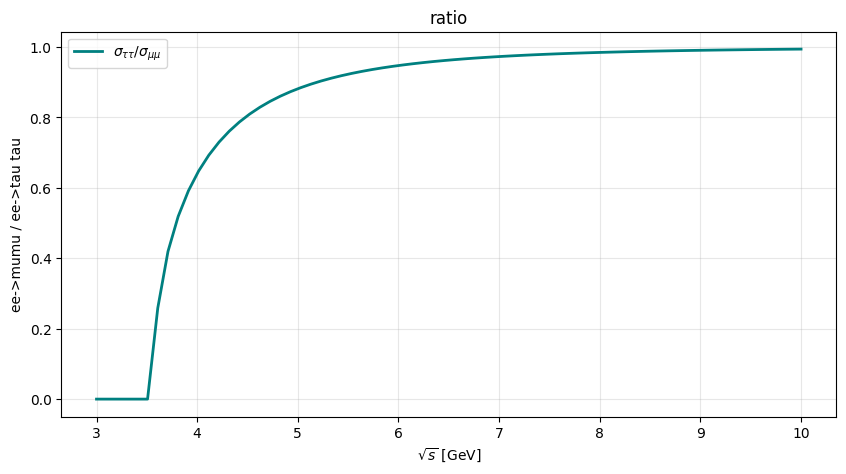

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson
from Kinematics import  kinematics2To2

plt.style.use('seaborn-v0_8-muted') 
plt.rcParams['axes.grid'] = True


# Capture 
py_expr = capture_physics_expr("ee_to_mumu", "dSigma")
print(f"Captured Expression: {py_expr}")

mMuon = 0.10566
mTau = 1.7768
alpha = 1/137.036

angles = np.linspace(0, np.pi, 100)
cos_theta = np.cos(angles)
sqrtS_vals = np.linspace(3.0, 10.0, 70)
sigma_mu = []
sigma_tau = []

# 2. Integration Loop
for E in sqrtS_vals:
    # --- Muon Calculation ---
    s, t, u, r = kinematics2To2(E, angles, m3=m_mu, m4=m_mu)
    if E > 2 * m_mu:
        dsig_mu = eval(py_expr, {
            "s": s, "t": t, "u": u, 
            "alpha": alpha, "Mass": mMuon, 
            "pfInOutRatio": r
        })
        # Integrate over d(cos theta)
        sigma_mu.append(simpson(dsig_mu, x=cos_theta))
    else:
        sigma_mu.append(np.nan)

    # --- Tau Calculation ---
    if E > 2 * m_tau:
        s, t, u, r = kinematics2To2(E, angles, m3=m_tau, m4=m_tau)
        dsig_tau = eval(py_expr, {
            "s": s, "t": t, "u": u, 
            "alpha": alpha, "Mass": mTau, 
            "pfInOutRatio": r
        })
        sigma_tau.append(simpson(dsig_tau, x=cos_theta))
    else:
        sigma_tau.append(0.0)

# 3. Compute Ratio
ratio_vals = np.array(sigma_tau) / np.array(sigma_mu)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(sqrtS_vals, ratio_vals, color='teal', lw=2, label=r'$\sigma_{\tau\tau}/\sigma_{\mu\mu}$')
plt.title("ratio")
plt.xlabel(r"$\sqrt{s}$ [GeV]")
plt.ylabel("ee->mumu / ee->tau tau")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()